## 构造非线性数据

In [78]:
import numpy as np
import matplotlib.pyplot as plt

In [79]:
x = np.random.uniform(-4, 2, size=100)  # 在区间 [-4, 2) 内随机生成 100 个均匀分布的 x 值
y = 2*x**2 + 4*x + 3 + np.random.randn(100)  # 根据二次函数生成 y，并加入随机噪声，使数据更接近真实情况

In [80]:
X = x.reshape(-1, 1)  # 将一维数组 x 转换为二维特征矩阵，形状为 (100, 1)

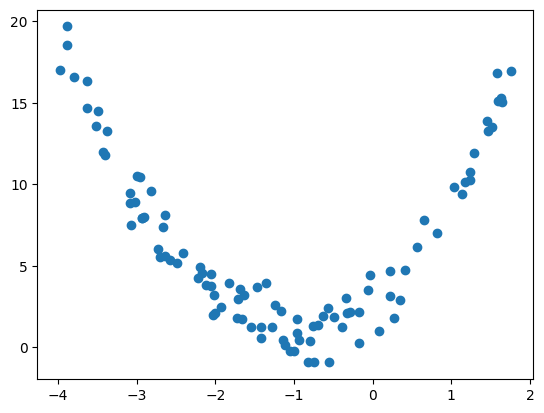

In [81]:
plt.scatter(X, y)
plt.show()

## 线性回归

In [82]:
from sklearn.linear_model import LinearRegression
linear_regression = LinearRegression()
linear_regression.fit(X, y)
y_predict = linear_regression.predict(X)

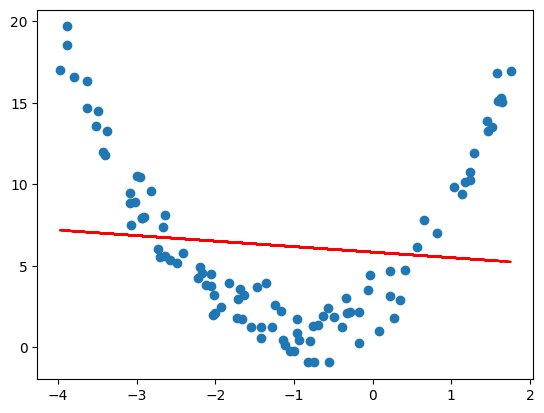

In [83]:
plt.scatter(x, y)
plt.plot(x, y_predict, color="red")
plt.show()

## 多项式回归

In [84]:
X[:5]  # 查看特征矩阵 X 的前 5 行

array([[-0.74594405],
       [-2.82042689],
       [-0.17728232],
       [ 1.46436794],
       [-0.62855388]])

In [85]:
X_new = np.hstack([X, X**2])  # 在原始特征 X 的基础上添加二次项 X²。转换前只有一列 x，转换后包含两列：x 和 x²

In [86]:
X_new[:5]  # 查看转换后特征矩阵的前 5 行

array([[-0.74594405,  0.55643253],
       [-2.82042689,  7.95480787],
       [-0.17728232,  0.03142902],
       [ 1.46436794,  2.14437346],
       [-0.62855388,  0.39507998]])

In [87]:
linear_regression_new = LinearRegression()  # 创建线性回归模型
linear_regression_new.fit(X_new, y);  # 使用扩展后的特征 X_new 和目标值 y 训练模型。模型实际拟合的形式为：y = b₀ + b₁x + b₂x²

In [88]:
y_predict_new = linear_regression_new.predict(X_new)  # 使用训练完成的模型，对全部样本进行预测

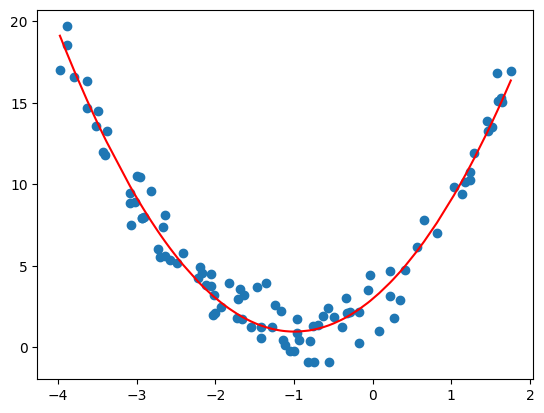

In [89]:
plt.scatter(x, y)
plt.plot(                          # 使用相同索引重新排列预测值，使拟合曲线能够按顺序连接
    np.sort(x),                    # np.sort(x) 将 x 按照从小到大的顺序排列
    y_predict_new[np.argsort(x)],  # np.argsort(x) 返回 x 从小到大排列时对应的索引
    color="red")
plt.show()

In [90]:
linear_regression_new.intercept_  # 查看模型的截距 b₀

np.float64(2.9680861748425516)

In [91]:
linear_regression_new.coef_  # 查看模型中各个特征对应的回归系数

array([4.04538595, 2.03907052])

## scikit-learn中的PolynomialFeatures

In [92]:
from sklearn.preprocessing import PolynomialFeatures  # 从 sklearn.preprocessing 模块中导入多项式特征转换工具

In [93]:
polynomial_features = PolynomialFeatures(degree=2)  # 创建 PolynomialFeatures 对象。degree=2 表示生成最高次数为 2 的多项式特征

In [94]:
X_poly = polynomial_features.fit_transform(X)  # 根据特征矩阵 X 学习转换规则，并将 X 转换为二次多项式特征矩阵。对于只有一个特征 x 的情况，转换结果通常为：[1, x, x²]

In [95]:
X_poly[:5]  # 查看转换后特征矩阵的前 5 行

array([[ 1.        , -0.74594405,  0.55643253],
       [ 1.        , -2.82042689,  7.95480787],
       [ 1.        , -0.17728232,  0.03142902],
       [ 1.        ,  1.46436794,  2.14437346],
       [ 1.        , -0.62855388,  0.39507998]])